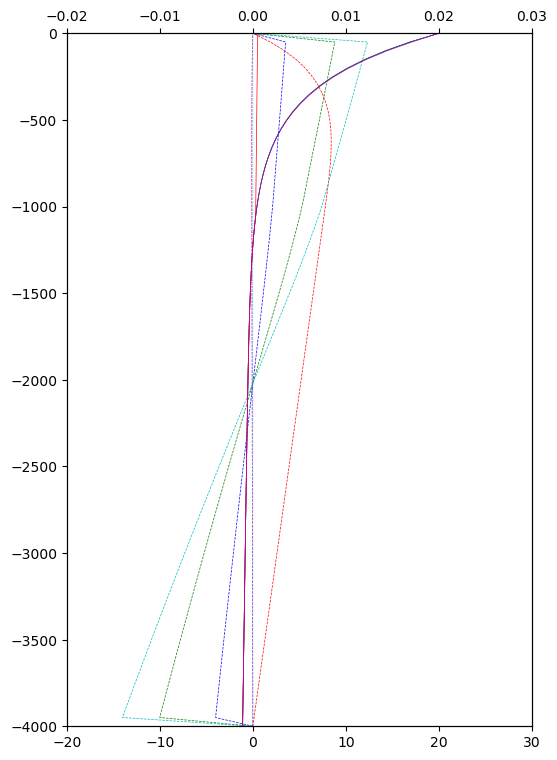

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


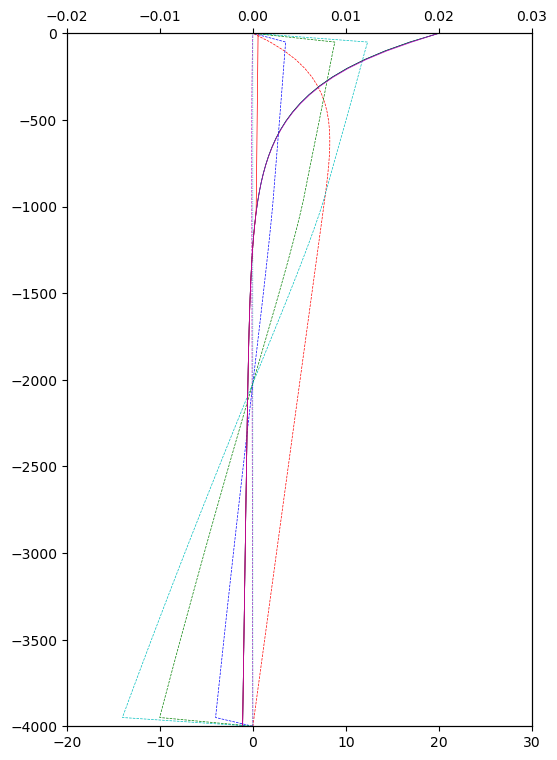

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


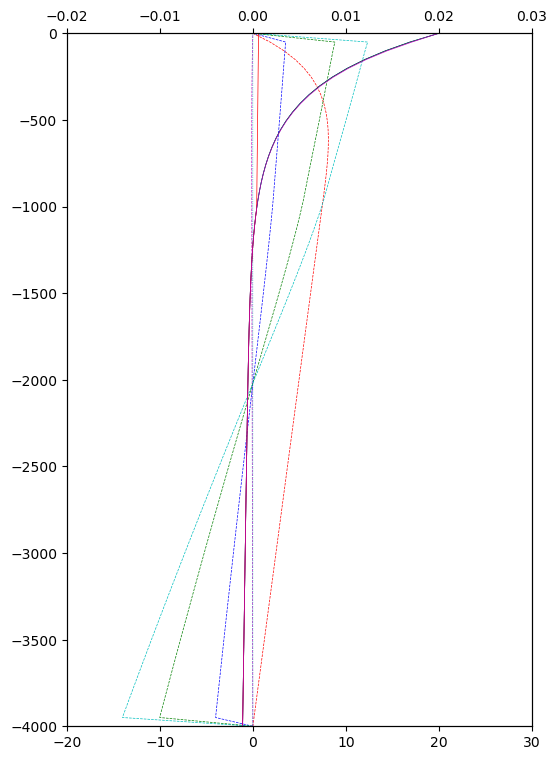

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


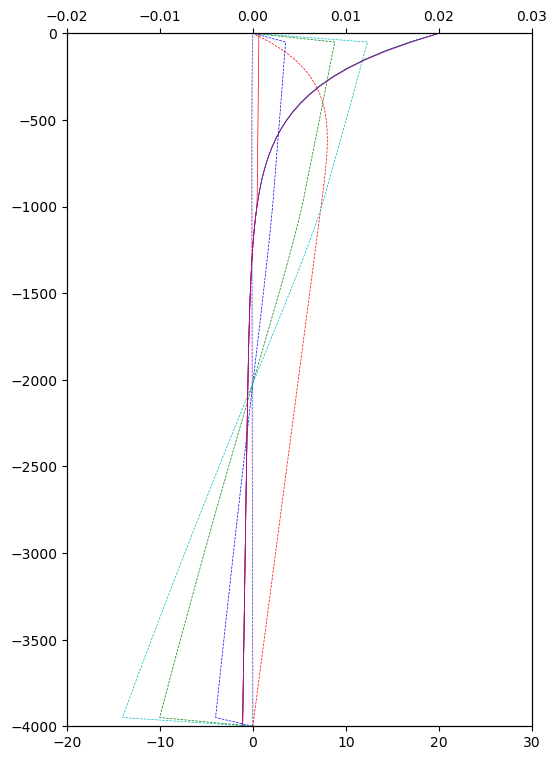

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


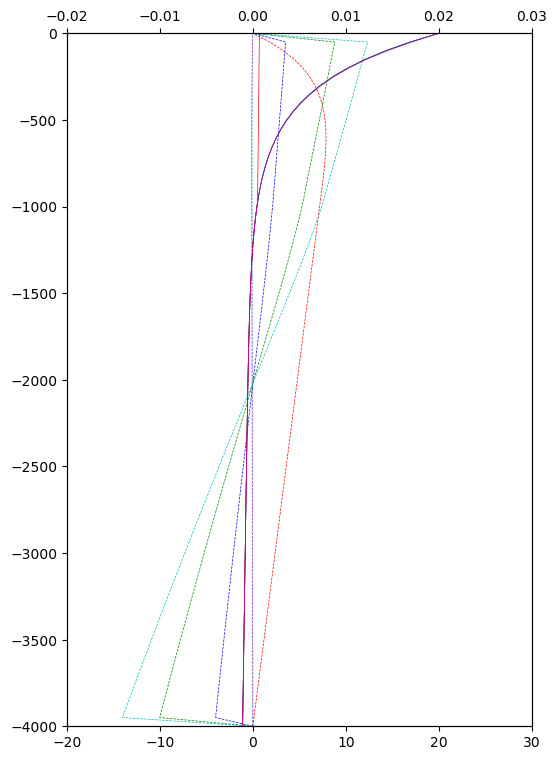

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years
   bs_north_pac  bs_north  Global_z_max_SV  Global_z_max_z_m  \
0          0.02   0.00030        14.122415       -759.493671   
1          0.02   0.00035        14.022029       -759.493671   
2          0.02   0.00040        13.894881       -759.493671   
3          0.02   0.00045        13.796240       -708.860759   
4          0.02   0.00050        13.700347       -708.860759   

   Pacific_z_max_SV  Atlantic_z_max_SV  AMOC_max_SV  
0          0.007167          14.279507    14.279507  
1          0.007130          14.177942    14.177942  
2          0.007086          14.049295    14.049295  
3          0.007042          13.947983    13.947983  
4          0.007009          13.845682    13.845682  


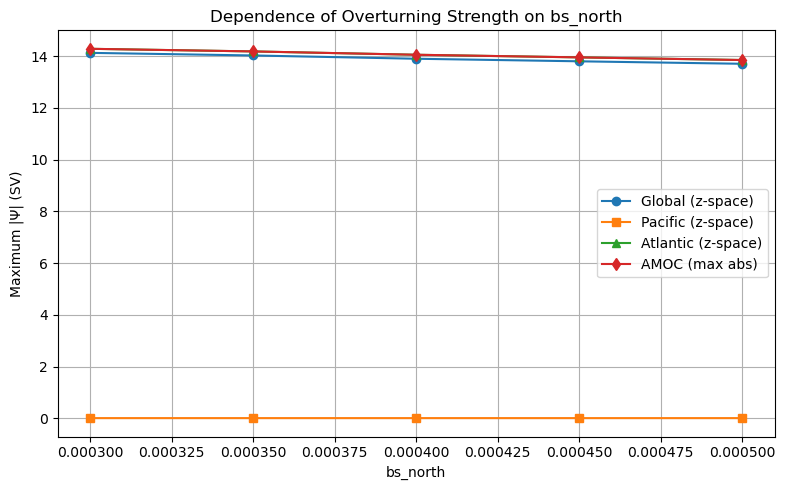

In [9]:
"""
Four-column MOC model, allowing for Northern sinking in the Pacific and the development of a PMOC.
"""

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

diag_file = None

# Set the Pacific northern sinking buoyancy
bs_north_pac_vals = [0.02]

# Sweep of Atlantic northern sinking buoyancy
bs_north_sweep = np.linspace(0.0003, 0.0005, 5)

psi_sweep_results = []

for bs_north_pac in bs_north_pac_vals:
    for bs_north in bs_north_sweep:

        bs = 0.02
        bAABW = -0.0011
        bbot = min(bAABW, bs_north, bs_north_pac)

        # S.O. surface boundary conditions and grid
        y = np.linspace(0, 3.e6, 51)
        tau = 0.16
        offset = 0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6))
        bs_SO = (0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
                 + (bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)
                 + offset*(y<5.55e5))

        dt = 86400.*30
        MOC_up_iters = int(np.floor(2.*360*86400/dt))
        plot_iters = int(np.ceil(500*360*86400/dt))
        total_iters = int(np.ceil(4000*360*86400/dt))

        z = np.linspace(-4000, 0, 80)
        N2min = 2e-7

        def kappaeff(z):
            return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                         *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )

        A_Atl = 7e13
        A_north_atl = 5.5e12
        A_Pac = 1.7e14 - 5.5e12
        A_north_pac = 5.5e12

        Lx = 1.3e7
        Latl = 6./21.*Lx
        Lpac = 15./21.*Lx
        K = 1800.

        def b_Atl(z): return bs*np.exp(z/300.) + z/z[0]*bbot
        def b_Pac(z): return bs*np.exp(z/300.) + z/z[0]*bbot

        # Overturning models
        AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01*b_Atl(z))
        AMOC.solve()
        Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

        PMOC = Psi_Thermwind(z=z, b1=b_Pac, b2=0.01*b_Pac(z))
        PMOC.solve()
        Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

        ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
        ZOC.solve()
        Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

        SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
        SO_Atl.solve()
        SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
        SO_Pac.solve()

        Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
        north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north_atl, N2min=N2min)
        Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)
        north_Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs_north_pac, bbot=bbot, Area=A_north_pac, N2min=N2min)

        # Create figure for iterative plotting
        fig = plt.figure(figsize=(6,9))
        ax1 = fig.add_subplot(111)
        ax2 = ax1.twiny()
        plt.ylim((-4000,0))
        ax1.set_xlim((-20,30))
        ax2.set_xlim((-0.02,0.030))

        # Time-stepping loop
        for ii in range(total_iters):
            wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
            wAN = -Psi_iso_N * 1e6
            wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_iso_Pac) * 1e6
            wA_NPac = -Psi_iso_NPac * 1e6

            Atl.timestep(wA=wA_Atl, dt=dt)
            north.timestep(wA=wAN, dt=dt, do_conv=True)
            Pac.timestep(wA=wA_Pac, dt=dt)
            north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True)

            if ii % MOC_up_iters == 0:
                AMOC.update(b1=Atl.b, b2=north.b)
                AMOC.solve()
                Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

                PMOC.update(b1=Pac.b, b2=north_Pac.b)
                PMOC.solve()
                Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

                ZOC.update(b1=Atl.b, b2=Pac.b)
                ZOC.solve()
                Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

                SO_Atl.update(b=Atl.b)
                SO_Atl.solve()
                SO_Pac.update(b=Pac.b)
                SO_Pac.solve()

            if ii % plot_iters == 0:
                ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=0.5)
                ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=0.5)
                ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
                ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
                ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
                ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=0.5)
                ax2.plot(Atl.b, Atl.z, '-b', linewidth=0.5)
                ax2.plot(Pac.b, Pac.z, '-g', linewidth=0.5)
                ax2.plot(north.b, north.z, '-r', linewidth=0.5)
                ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=0.5)
                plt.pause(0.01)
                print("t=", round(ii*dt/86400/360), "years")

        # Final plots, diagnostics, sweep results collection...
        # [rest of the plotting and results collection code remains identical, including saving figures]

        # Append sweep results
        psi_sweep_results.append({
            'bs_north_pac': bs_north_pac,
            'bs_north': bs_north,
            'Global_z_max_SV': float(np.abs(np.max(AMOC.Psi + PMOC.Psi))),
            'Global_z_max_z_m': float(z[np.nanargmax(AMOC.Psi + PMOC.Psi)]),
            'Pacific_z_max_SV': float(np.abs(np.max(PMOC.Psi))),
            'Atlantic_z_max_SV': float(np.abs(np.max(AMOC.Psi))),
            'AMOC_max_SV': float(np.abs(np.max(AMOC.Psi))),
        })

        plt.close('all')

# After sweeps, collate results
if len(psi_sweep_results) > 0:
    df_results = pd.DataFrame(psi_sweep_results)
    print(df_results)

    plt.figure(figsize=(8,5))
    plt.plot(df_results['bs_north'], df_results['Global_z_max_SV'], marker='o', label='Global (z-space)')
    plt.plot(df_results['bs_north'], df_results['Pacific_z_max_SV'], marker='s', label='Pacific (z-space)')
    plt.plot(df_results['bs_north'], df_results['Atlantic_z_max_SV'], marker='^', label='Atlantic (z-space)')
    plt.plot(df_results['bs_north'], df_results['AMOC_max_SV'], marker='d', label='AMOC (max abs)')
    plt.xlabel('bs_north')
    plt.ylabel('Maximum |Ψ| (SV)')
    plt.title('Dependence of Overturning Strength on bs_north')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('psi_vs_bsnorth_sweep.png')
    plt.show()
else:
    print("No sweep results collected.")
